In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing


## Load data


In [2]:
df = pd.read_csv('rea_games_dataset_updated.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Game ID                 50000 non-null  object 
 1   Game Name               50000 non-null  object 
 2   Platform                50000 non-null  object 
 3   Genre                   50000 non-null  object 
 4   Release Date            50000 non-null  object 
 5   Sales (Million $)       50000 non-null  float64
 6   Player Count (Million)  50000 non-null  float64
 7   Region                  50000 non-null  object 
 8   Age Group               50000 non-null  object 
 9   Gender                  50000 non-null  object 
 10  Rating                  50000 non-null  int64  
dtypes: float64(2), int64(1), object(8)
memory usage: 4.2+ MB


-   Пропущенных значений нет.
-   Используем `Game ID` в качестве индекса


In [3]:
# Replace index with "Game ID"
df.loc[:, "Game ID"] = df["Game ID"].apply(lambda x:
                                           pd.to_numeric(x.removeprefix("GAME"), errors='coerce'))
df.set_index("Game ID", inplace=True)

## Числовые признаки


-   Из даты выделим 2 числовых признака: год и месяц выпуска.
-   День выпуска вряд ли важен.


In [4]:
# Replace "Release Date" with numerical feature "Release Month"

df["Release Month"] = (pd.to_datetime(df["Release Date"]).dt.year - 2014)*12 + \
    pd.to_datetime(df["Release Date"]).dt.month
df.drop(["Release Date"], axis=1, inplace=True)

In [5]:
# Отделяем цифровые колонки в отдельный датасет для анализа признаков
df_numerics = df[df._get_numeric_data().columns]
df_numerics.head()

,Sales (Million $),Player Count (Million),Rating,Release Month
Game ID,,,,
1,56.06,25.41,1,93
2,81.41,41.88,8,129
3,44.51,47.32,8,128
4,91.69,32.97,8,103
5,79.79,39.50,8,50


In [6]:
df_numerics.describe()

,Sales (Million $),Player Count (Million),Rating,Release Month
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,50.216254,24.974368,5.511440,69.743140
std,28.645562,14.357901,2.880957,34.622197
min,0.500000,0.100000,1.000000,10.000000
25%,25.517500,12.520000,3.000000,40.000000
50%,50.335000,24.950000,6.000000,70.000000
75%,75.040000,37.380000,8.000000,100.000000
max,100.000000,50.000000,10.000000,130.000000


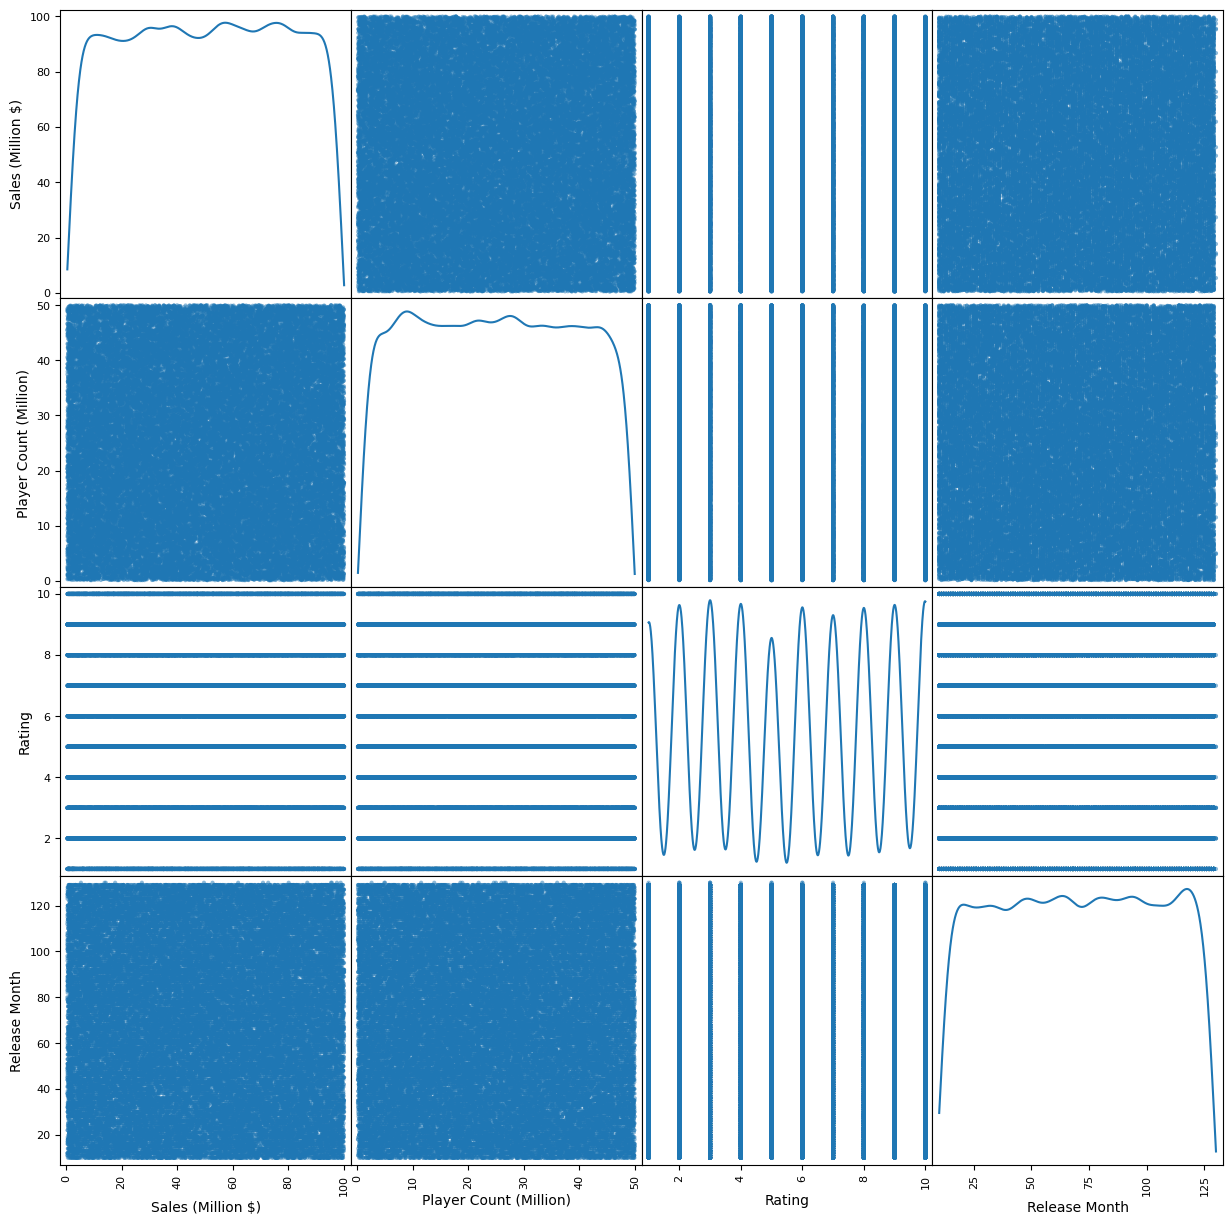

In [7]:
pd.plotting.scatter_matrix(
    df_numerics, figsize=(15, 15), diagonal="kde"
)
plt.show()

<Axes: >

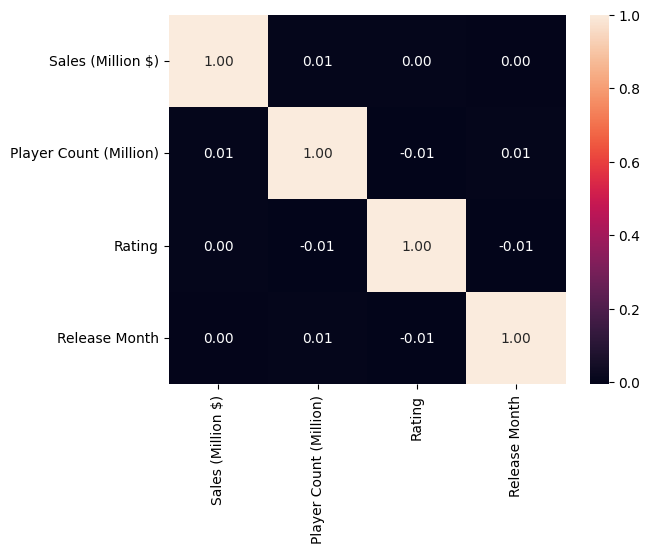

In [8]:
sns.heatmap(df_numerics.corr(method='kendall'), annot=True, fmt='.2f')

## Категориальные признаки


In [9]:
categorial_cols = list(set(df.columns) - set(df._get_numeric_data().columns))
print(categorial_cols)

['Platform', 'Region', 'Genre', 'Game Name', 'Age Group', 'Gender']


In [10]:
for col in df[categorial_cols].columns:
    print(df[col].value_counts())
    print("\n")

Platform
Xbox               10071
Nintendo Switch    10018
PS5                 9984
Mobile              9983
PC                  9944
Name: count, dtype: int64


Region
Australia        10155
South America    10124
Asia             10089
Europe            9827
North America     9805
Name: count, dtype: int64


Genre
Adventure    8555
Shooter      8452
Sports       8317
Strategy     8294
RPG          8283
Action       8099
Name: count, dtype: int64


Game Name
Send.                    14
Great.                   13
And.                     12
Leg.                     11
She.                     10
                         ..
Area skin collection.     1
Two during remain.        1
Leave mouth.              1
Series because every.     1
Still adult toward.       1
Name: count, Length: 46393, dtype: int64


Age Group
10-18    10096
19-25    10061
46+      10043
26-35     9929
36-45     9871
Name: count, dtype: int64


Gender
Female    25049
Male      24951
Name: count, dtype: int64




-   Выкидываем колонку `Game Name` - много уникальных значений.
-   Остальные колонки содержат несколько достаточно сбалансированных классов. Их будем кодировать.


In [11]:
# Drop `Game Name` feature
df.drop(['Game Name'], axis=1, inplace=True)

In [12]:
categorial_cols = list(set(df.columns) - set(df._get_numeric_data().columns))
# print(categorial_cols)
for category in categorial_cols:
    df = pd.concat([df, pd.get_dummies(df[category], prefix=category)],
                   axis=1,
                   )
    df.drop([category],
            axis=1,
            inplace=True)

In [13]:
# Convert bool features into int
df = df*1

In [14]:
df.drop(['Genre_Strategy',
         'Gender_Male',
         'Platform_Xbox',
         'Age Group_46+',
         'Region_South America'], axis=1, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1 to 50000
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sales (Million $)         50000 non-null  float64
 1   Player Count (Million)    50000 non-null  float64
 2   Rating                    50000 non-null  int64  
 3   Release Month             50000 non-null  int32  
 4   Platform_Mobile           50000 non-null  int64  
 5   Platform_Nintendo Switch  50000 non-null  int64  
 6   Platform_PC               50000 non-null  int64  
 7   Platform_PS5              50000 non-null  int64  
 8   Region_Asia               50000 non-null  int64  
 9   Region_Australia          50000 non-null  int64  
 10  Region_Europe             50000 non-null  int64  
 11  Region_North America      50000 non-null  int64  
 12  Genre_Action              50000 non-null  int64  
 13  Genre_Adventure           50000 non-null  int64  
 14  Genre_RPG  

# Models


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## Задача

Используя все доступные вам методы анализа и обработки данных, и модели машинного обучения построить модель для `TARGET = Sales (Million $)` по метрике `mean_absolute_error`


In [17]:
df.head()

,Sales (Million $),Player Count (Million),Rating,Release Month,Platform_Mobile,Platform_Nintendo Switch,Platform_PC,Platform_PS5,Region_Asia,Region_Australia,...,Genre_Action,Genre_Adventure,Genre_RPG,Genre_Shooter,Genre_Sports,Age Group_10-18,Age Group_19-25,Age Group_26-35,Age Group_36-45,Gender_Female
Game ID,,,,,,,,,,,,,,,,,,,,,
1,56.06,25.41,1,93,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,81.41,41.88,8,129,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
3,44.51,47.32,8,128,0,0,1,0,1,0,...,0,0,0,0,1,1,0,0,0,0
4,91.69,32.97,8,103,0,0,1,0,0,1,...,0,0,0,0,1,0,1,0,0,0
5,79.79,39.50,8,50,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Sales (Million $)', axis=1)
Y = df['Sales (Million $)']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

## Linear Regression


In [19]:
pipe_lr = Pipeline(
    [
        ('Scaler', StandardScaler()),
        ('LR', LinearRegression())
    ]
)
pipe_lr.fit(X_train, Y_train)
Y_pred_lr = pipe_lr.predict(X_test)

## SVR


In [20]:
pipe_svr = Pipeline(
    [
        ('Scaler', StandardScaler()),
        ('LR', SVR(kernel='rbf'))
    ]
)
pipe_svr.fit(X_train, Y_train)
Y_pred_svr = pipe_svr.predict(X_test)

## KNN Regression


In [21]:
pipe_knn = Pipeline(
    [
        ('Scaler', StandardScaler()),
        ('LR', KNeighborsRegressor(n_neighbors=5))
    ]
)
pipe_knn.fit(X_train, Y_train)
Y_pred_knn = pipe_knn.predict(X_test)

## Results comparision


### MAE

In [22]:
mae_lr = mean_absolute_error(Y_test, Y_pred_lr)
mae_svr = mean_absolute_error(Y_test, Y_pred_svr)
mae_knn = mean_absolute_error(Y_test, Y_pred_knn)
print(f'MAE for LR = {mae_lr:.2f}')
print(f'MAE for SVR = {mae_svr:.2f}')
print(f'MAE for KNN = {mae_knn:.2f}')

MAE for LR = 24.80
MAE for SVR = 24.86
MAE for KNN = 26.34


### MAPE
Так как разброс целевой переменной `[0.5, 200]`, то более информативна будет метрика MAPE

In [23]:
mape_lr = mean_absolute_percentage_error(Y_test, Y_pred_lr)
mape_svr = mean_absolute_percentage_error(Y_test, Y_pred_svr)
mape_knn = mean_absolute_percentage_error(Y_test, Y_pred_knn)
print(f'MAPE for LR = {mape_lr:.2f}%')
print(f'MAPE for SVR = {mape_svr:.2f}%')
print(f'MAPE for KNN = {mape_knn:.2f}%')

MAPE for LR = 1.96%
MAPE for SVR = 1.96%
MAPE for KNN = 1.99%
